In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio

from sklearn.datasets import load_wine
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)


DATA_DIR = Path('data')

if not DATA_DIR.exists():
    DATA_DIR = Path('.')

print('Directorio de datos:', DATA_DIR.resolve())

Directorio de datos: C:\Users\User\OneDrive\Desktop\AprendizajeAutomatico\TrabajoPractico_6\data


In [3]:
def plot_labeled_points(X, y, title, xlabel='x1', ylabel='x2'):
    plt.figure(figsize=(7, 5))
    markers = ['o', 's', '^', 'v', 'D', 'P']
    for idx, label in enumerate(np.unique(y)):
        plt.scatter(
            X[y == label, 0],
            X[y == label, 1],
            marker=markers[idx % len(markers)],
            alpha=0.75,
            label=f'Clase {label}',
        )
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()


def plot_decision_boundary(model, X, y, title, show_support=True, step=0.02):
    x1_min, x1_max = X[:, 0].min() - 0.1 * np.ptp(X[:, 0]), X[:, 0].max() + 0.1 * np.ptp(X[:, 0])
    x2_min, x2_max = X[:, 1].min() - 0.1 * np.ptp(X[:, 1]), X[:, 1].max() + 0.1 * np.ptp(X[:, 1])

    n_grid = 260
    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, n_grid),
        np.linspace(x2_min, x2_max, n_grid),
    )
    grid = np.column_stack([xx1.ravel(), xx2.ravel()])
    pred = model.predict(grid).reshape(xx1.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx1, xx2, pred, alpha=0.18)
    plt.contour(xx1, xx2, pred, levels=np.unique(y)[:-1] + 0.5, linewidths=1.2)

    markers = ['o', 's', '^', 'v']
    for idx, label in enumerate(np.unique(y)):
        plt.scatter(
            X[y == label, 0],
            X[y == label, 1],
            marker=markers[idx % len(markers)],
            alpha=0.8,
            label=f'Clase {label}',
        )

    if show_support and hasattr(model, 'named_steps') and 'svc' in model.named_steps:
        support_idx = model.named_steps['svc'].support_
        plt.scatter(
            X[support_idx, 0],
            X[support_idx, 1],
            s=120,
            facecolors='none',
            linewidths=1.6,
            label='Vectores de soporte',
        )

    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.legend()
    plt.show()

## 2. Carga y exploración del Wine dataset
Cargue el dataset y responda:

¿Cuántas muestras, variables predictoras y clases tiene?
¿Las clases tienen exactamente la misma cantidad de muestras?

In [4]:
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
class_names = wine.target_names
print('X:', X.shape)
print('y:', y.shape)
print('Clases:', np.unique(y))
print('Cantidad por clase:')
print(pd.Series(y).value_counts().sort_index())

X: (178, 13)
y: (178,)
Clases: [0 1 2]
Cantidad por clase:
0    59
1    71
2    48
Name: count, dtype: int64


El dataset Wine contiene 178 muestras y 13 variables predictoras. El problema de clasificación presenta 3 clases diferentes, identificadas mediante las etiquetas 0, 1 y 2.

Las clases no tienen exactamente la misma cantidad de muestras. La clase 0 contiene 59 muestras, la clase 1 contiene 71 muestras y la clase 2 contiene 48 muestras. Por lo tanto, existe un cierto desbalance entre las clases, aunque ninguna de ellas es realmente apreciable

## 3. División en entrenamiento y prueba
La notebook indica reservar un conjunto de prueba que permanezca fuera del entrenamiento utilizando:
test_size=0.30
random_state=42
stratify=y

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print('Train:', X_train.shape)
print('Test:', X_test.shape)

Train: (124, 13)
Test: (54, 13)


Se utilizó el 70 % de las muestras para entrenamiento y el 30 % restante para prueba. Como el dataset contiene 178 muestras, se obtuvieron 124 muestras para entrenamiento y 54 para prueba.

La opción stratify=y permite mantener aproximadamente la misma proporción de las tres clases en ambos conjuntos. De esta manera, la partición resulta más representativa de la distribución original de las clases.

El parámetro random_state=42 permite reproducir exactamente la misma división cada vez que se ejecuta el código

## 4. Estandarización para la implementación manual
La notebook indica escalar las características para realizar la implementación manual de LDA y mantener estabilidad numérica.

In [6]:
scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

print('Train estandarizado:', X_train_std.shape)
print('Test estandarizado:', X_test_std.shape)

Train estandarizado: (124, 13)
Test estandarizado: (54, 13)


Las características fueron estandarizadas utilizando StandardScaler. El escalador se ajustó únicamente utilizando el conjunto de entrenamiento mediante fit_transform, y posteriormente se aplicó la misma transformación al conjunto de prueba mediante transform.
En este caso, la estandarización no se realiza porque LDA dependa directamente de distancias euclidianas, sino principalmente para facilitar el procedimiento matricial y mantener un flujo de trabajo homogéneo.

## 5. Implementación guiada de LDA como reducción de dimensionalidad


5.1. Vectores de medias por clase
Calcular el vector de medias de cada una de las clases utilizando los datos de entrenamiento estandarizados.

In [7]:
classes = np.unique(y_train)
mean_vectors = []
for label in classes:
    mean_vec = X_train_std[y_train == label].mean(axis=0)
    mean_vectors.append(mean_vec)
    print(f'Clase {label} - vector de medias:')
    print(mean_vec)
    print()

Clase 0 - vector de medias:
[ 0.95854072 -0.32201521  0.32191667 -0.76072471  0.43459496  0.85738095
  0.98093415 -0.4969177   0.42608046  0.2418433   0.42513874  0.71394348
  1.18789118]

Clase 1 - vector de medias:
[-0.88291481 -0.30730723 -0.48748321  0.25359916 -0.32297732 -0.06318934
  0.04173645 -0.07842567  0.18495572 -0.85746433  0.45982254  0.29459356
 -0.70747471]

Clase 2 - vector de medias:
[ 0.14683548  0.86569652  0.33865384  0.56090167 -0.05059175 -0.96948946
 -1.28197342  0.73620937 -0.80960862  0.9987164  -1.22490349 -1.33337457
 -0.40393341]



Para cada clase se calculó un vector de medias compuesto por 13 valores, uno correspondiente a cada variable predictora del dataset Wine.
Estos vectores representan el centro de cada clase en el espacio de características estandarizado. Son necesarios para calcular posteriormente las matrices de dispersión intra-clase y entre-clases.

5.2. Matriz de dispersión intra-clase SW
Construir la matriz de dispersión intra-clase SW, que acumula la variabilidad de las muestras alrededor de la media de su propia clase.

In [8]:
d = X_train_std.shape[1]
S_W = np.zeros((d, d))

for label, mean_vec in zip(classes, mean_vectors):
    X_class = X_train_std[y_train == label]
    centered = X_class - mean_vec
    S_W += centered.T @ centered

print('Dimensión de S_W:', S_W.shape)

Dimensión de S_W: (13, 13)


La matriz de dispersión intra-clase SW tiene dimensión 13 × 13, ya que el dataset posee 13 variables predictoras.
Esta matriz representa la variabilidad existente dentro de las clases. Para cada clase se calculan las diferencias entre las muestras y el vector de medias correspondiente, y esas diferencias se acumulan mediante el producto matricial.
Una matriz SW pequeña en determinadas direcciones indica que las muestras de una misma clase están relativamente concentradas en esas direcciones. LDA busca aprovechar esta información junto con la dispersión entre clases para encontrar direcciones que permitan discriminar mejor las categorías

5.3. Matriz de dispersión entre-clases SB
Construir la matriz de dispersión entre-clases SB, considerando la distancia entre las medias de cada clase y la media global.

In [9]:
mean_overall = X_train_std.mean(axis=0)
S_B = np.zeros((d, d))

for label, mean_vec in zip(classes, mean_vectors):
    n_i = np.sum(y_train == label)
    mean_diff = (mean_vec - mean_overall).reshape(d, 1)
    S_B += n_i * (mean_diff @ mean_diff.T)

print('Dimensión de S_B:', S_B.shape)

Dimensión de S_B: (13, 13)


La matriz de dispersión entre-clases SB también tiene dimensión 13 × 13 porque se construye a partir de las 13 variables predictoras.
A diferencia de SW, que representa la variabilidad dentro de cada clase, SB representa la separación entre las diferentes clases. Para calcularla se compara el vector de medias de cada clase con la media global y se pondera cada contribución según la cantidad de muestras de esa clase.
Por lo tanto, LDA busca direcciones donde la dispersión entre las clases sea grande en relación con la dispersión existente dentro de cada clase.

5.4. Problema de autovalores y matriz de proyección
Construir la matriz asociada al problema de autovalores, ordenar los autovalores y seleccionar los dos autovectores principales para formar la matriz de proyección W.

In [10]:
matrix_lda = np.linalg.pinv(S_W) @ S_B
eigen_vals, eigen_vecs = np.linalg.eig(matrix_lda)

eigen_pairs = [
    (eigen_vals[i].real, eigen_vecs[:, i].real)
    for i in range(len(eigen_vals))
]

eigen_pairs = sorted(eigen_pairs, key=lambda pair: pair[0], reverse=True)

print('Mayores autovalores:')
for value, _ in eigen_pairs:
    print(f'{value:.6f}')

W = np.column_stack([eigen_pairs[0][1], eigen_pairs[1][1]])
print('\nDimensión de W:', W.shape)

Mayores autovalores:
9.932534
4.960436
0.000000
0.000000
0.000000
0.000000
0.000000
0.000000
0.000000
0.000000
-0.000000
-0.000000
-0.000000

Dimensión de W: (13, 2)


¿Qué dimensión tiene W? ¿Por qué?
La matriz W tiene dimensión 13 × 2.
Esto se debe a que el dataset original tiene 13 variables predictoras y el procedimiento selecciona los dos autovectores asociados a los mayores autovalores. Cada autovector tiene 13 componentes, por lo que al colocarlos como columnas se obtiene una matriz de 13 filas y 2 columnas.
La matriz W permite transformar los datos desde el espacio original de 13 dimensiones hacia un espacio discriminante de 2 dimensiones.

¿Por qué aparecen solamente dos autovalores importantes aunque el dataset tenga 13 variables? ¿Cuántas dimensiones tiene el espacio discriminante?
Aunque el dataset tiene 13 variables predictoras, existen solamente 3 clases. En LDA multiclase, el número máximo de dimensiones discriminantes es min(p, c − 1), donde p es el número de variables y c es el número de clases.
min(13, 3 − 1) = 2
Por lo tanto, el espacio discriminante tiene como máximo 2 dimensiones. Esto explica por qué solamente aparecen dos autovalores relevantes y los restantes son prácticamente cero.

¿Qué significa geométricamente que las clases se separen mejor después de la proyección?
Geométricamente, significa que LDA encontró direcciones de proyección que maximizan la separación entre las clases y, al mismo tiempo, reducen relativamente la dispersión de las muestras pertenecientes a una misma clase.
Al proyectar los datos sobre estas direcciones, las muestras de una misma clase tienden a quedar agrupadas y los grupos correspondientes a diferentes clases tienden a quedar más separados. Por lo tanto, la representación en el espacio LDA conserva las características más relevantes para distinguir las etiquetas

5.5. Proyección al espacio LDA
Obtener la representación de los datos en el espacio LDA mediante la matriz de proyección obtenida anteriormente y visualizar las dos dimensiones discriminantes.

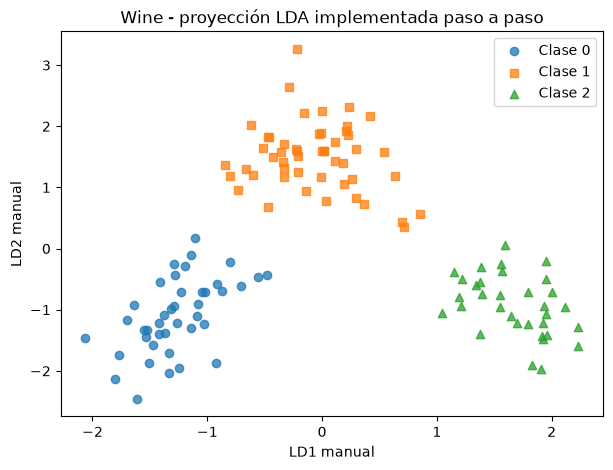

In [11]:
X_train_lda_manual = X_train_std @ W
X_test_lda_manual = X_test_std @ W

plt.figure(figsize=(7, 5))
markers = ['o', 's', '^']
for idx, label in enumerate(classes):
    plt.scatter(
        X_train_lda_manual[y_train == label, 0],
        X_train_lda_manual[y_train == label, 1],
        marker=markers[idx],
        alpha=0.75,
        label=f'Clase {label}',
    )

plt.xlabel('LD1 manual')
plt.ylabel('LD2 manual')
plt.title('Wine - proyección LDA implementada paso a paso')
plt.legend()
plt.show()

La gráfica permite observar las tres clases proyectadas sobre las dos direcciones discriminantes LD1 y LD2. La representación permite visualizar la separación entre las clases en un espacio de solamente dos dimensiones, a pesar de que originalmente el dataset posee 13 variables.

## 6. LDA con scikit-learn como transformación supervisada
Utilice LinearDiscriminantAnalysis(n_components=2) y compare la representación obtenida con la implementación manual.

In [12]:
lda_sklearn = LinearDiscriminantAnalysis(n_components=2)

X_train_lda = lda_sklearn.fit_transform(
    X_train_std,
    y_train
)

X_test_lda = lda_sklearn.transform(
    X_test_std
)

print('Dimensión:', X_train_lda.shape)
print('Explained variance ratio:',
      lda_sklearn.explained_variance_ratio_)

Dimensión: (124, 2)
Explained variance ratio: [0.6669277 0.3330723]


¿La proyección de scikit-learn debe ser idéntica punto por punto a la implementación manual?
La proyección de scikit-learn no tiene por qué ser idéntica punto por punto a la implementación manual. Ambas implementaciones buscan las mismas direcciones discriminantes, pero pueden producir representaciones diferentes debido a decisiones numéricas y de implementación. Además, los autovectores pueden estar expresados con una orientación o signo diferente.

¿Qué significan los valores de explained_variance_ratio_ del LDA de scikit-learn?
Los valores de explained_variance_ratio_ indican la proporción relativa de la capacidad discriminante asociada a cada componente. En esta ejecución, el primer componente representa aproximadamente el 66,69 % y el segundo aproximadamente el 33,31 %. En conjunto, los dos componentes representan el 100 % de la información discriminante disponible, ya que para tres clases existen como máximo dos dimensiones discriminantes.

¿Por qué el signo de un eje discriminante puede aparecer invertido sin que exista un error?
El signo de un eje discriminante puede aparecer invertido porque un autovector y su negativo representan exactamente la misma dirección matemática. Por ejemplo, w y -w definen el mismo eje, aunque las coordenadas proyectadas cambien de signo. Por este motivo, que un eje aparezca invertido no significa que exista un error en la implementación.

## 7. LDA como clasificador

Utilice LDA directamente como clasificador y evalúe su desempeño sobre el conjunto de prueba reservado. Calcule también la matriz de confusión.

Accuracy: 0.9814814814814815
Matriz de confusión:
[[18  0  0]
 [ 1 20  0]
 [ 0  0 15]]


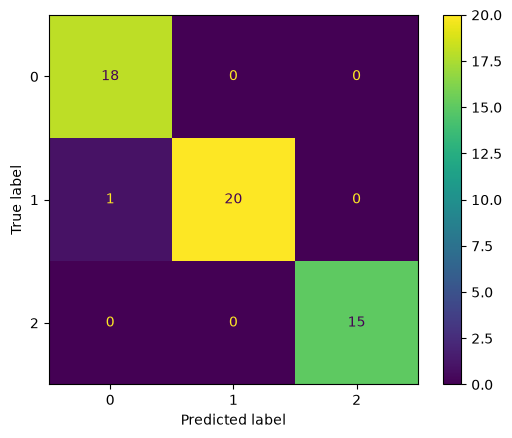

In [13]:
lda_classifier = LinearDiscriminantAnalysis()

lda_classifier.fit(
    X_train_std,
    y_train
)

y_pred_lda = lda_classifier.predict(
    X_test_std
)

accuracy_lda = accuracy_score(
    y_test,
    y_pred_lda
)

cm_lda = confusion_matrix(
    y_test,
    y_pred_lda
)

print('Accuracy:', accuracy_lda)
print('Matriz de confusión:')
print(cm_lda)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lda
)

disp.plot()
plt.show()

¿Cuántas muestras fueron clasificadas incorrectamente?
Se clasificó incorrectamente 1 muestra de las 54 pertenecientes al conjunto de prueba. Por lo tanto, 53 muestras fueron clasificadas correctamente y la accuracy obtenida fue aproximadamente 98,15 %

¿Qué diferencia conceptual existe entre usar LDA con transform() y usarlo con predict()?
transform() utiliza LDA como una transformación supervisada: toma las variables originales y las proyecta sobre el espacio discriminante de menor dimensión. En cambio, predict() utiliza LDA como clasificador y devuelve directamente la clase predicha para cada muestra

¿La frontera de decisión de LDA es lineal o no lineal?
La frontera de decisión de LDA es lineal. El modelo establece fronteras lineales entre las clases bajo el modelo discriminante utilizado. Por lo tanto, aunque la representación pueda cambiar mediante la proyección, las reglas de decisión de LDA son lineales en el espacio de características.

## 8. Validación cruzada
Calcule los cinco accuracies de validación cruzada de LDA sobre X_train, y_train usando cross_val_score de scikit-learn y reporte media y desviación estándar.

In [14]:
lda_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis())
])

cv_scores_lda = cross_val_score(
    lda_pipeline,
    X_train,
    y_train,
    cv=5
)

print('Accuracies:', cv_scores_lda)
print('Media:', cv_scores_lda.mean())
print('Desviación estándar:', cv_scores_lda.std())

Accuracies: [0.96 0.96 1.   1.   1.  ]
Media: 0.984
Desviación estándar: 0.019595917942265444


¿Por qué aparecen cinco valores de accuracy?
Aparecen cinco valores de accuracy porque se utilizó una validación cruzada con cv=5. El conjunto de entrenamiento se divide en cinco particiones y cada una actúa una vez como conjunto de validación, mientras que las otras cuatro se utilizan para entrenar el modelo.

¿Qué representa la media de esos valores?
La media de los cinco valores representa el desempeño promedio de LDA sobre las distintas particiones utilizadas durante la validación cruzada. En esta ejecución, la media fue 0.984, equivalente al 98,40 %.

¿Qué información aporta la desviación estándar?
La desviación estándar indica cuánto varían los resultados entre las diferentes particiones. En este caso fue aproximadamente 0.0196, lo que indica que existe una variación relativamente pequeña entre los distintos folds.

¿Validación cruzada y búsqueda de hiperparámetros son lo mismo?
No son lo mismo. La validación cruzada es un procedimiento para estimar el desempeño de un modelo utilizando diferentes particiones de los datos. La búsqueda de hiperparámetros, en cambio, consiste en comparar distintas configuraciones del modelo para seleccionar aquella que presenta el mejor desempeño. La validación cruzada puede utilizarse como parte del proceso de búsqueda de hiperparámetros, pero ambos conceptos no son equivalentes

## 9. Efecto del escalado en LDA
Compare mediante validación cruzada LDA con y sin StandardScaler.

In [15]:
lda_scores_scaled = cross_val_score(
    Pipeline([
        ('scaler', StandardScaler()),
        ('lda', LinearDiscriminantAnalysis())
    ]),
    X_train,
    y_train,
    cv=5
)

lda_scores_no_scaled = cross_val_score(
    LinearDiscriminantAnalysis(),
    X_train,
    y_train,
    cv=5
)

print('Con StandardScaler:')
print(lda_scores_scaled)
print('Media:', lda_scores_scaled.mean())
print('Desvío:', lda_scores_scaled.std())

print('\nSin StandardScaler:')
print(lda_scores_no_scaled)
print('Media:', lda_scores_no_scaled.mean())
print('Desvío:', lda_scores_no_scaled.std())

Con StandardScaler:
[0.96 0.96 1.   1.   1.  ]
Media: 0.984
Desvío: 0.019595917942265444

Sin StandardScaler:
[0.96 0.96 1.   1.   1.  ]
Media: 0.984
Desvío: 0.019595917942265444


En esta ejecución, LDA obtuvo exactamente los mismos resultados de validación cruzada con y sin StandardScaler: una media de 0.984 y una desviación estándar aproximada de 0.0196.
Esto es consistente con lo indicado en la notebook: LDA clásico no depende de las distancias euclidianas de la misma manera que KNN o SVM. Bajo una transformación lineal invertible de escala, la regla discriminante no debería cambiar esencialmente.
En este ejercicio, por lo tanto, el escalado se utiliza principalmente para favorecer la estabilidad numérica de la implementación manual y mantener un flujo de trabajo homogéneo, pero no produjo una mejora en el desempeño de LDA.

## PARTE B — MÁQUINAS DE SOPORTE VECTORIAL (SVM)

## 11. Dataset 1: efecto de C y de una observación atípica
Entrene SVM lineales con C ∈ {0.01, 1, 100} y analice cómo cambia la frontera, el número de vectores de soporte y el ajuste al dato atípico.
Use la función plot_decision_boundary provista al inicio de la notebook.

In [16]:
from pathlib import Path
import warnings
import scipy.io as sio

DATA_DIR = Path('data')

if not DATA_DIR.exists():
    DATA_DIR = Path('.')

print('Directorio de datos:', DATA_DIR.resolve())

Directorio de datos: C:\Users\User\OneDrive\Desktop\AprendizajeAutomatico\TrabajoPractico_6\data


Dimensiones: (51, 2)
Clases: [0 1]


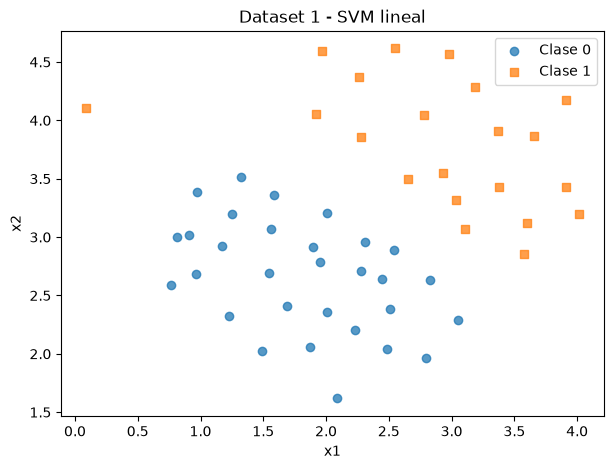

In [17]:
mat1 = sio.loadmat(DATA_DIR / 'data1.mat')
X_svm1 = mat1['X']
y_svm1 = mat1['y'].ravel()

print('Dimensiones:', X_svm1.shape)
print('Clases:', np.unique(y_svm1))

plot_labeled_points(
    X_svm1,
    y_svm1,
    'Dataset 1 - SVM lineal'
)

C: 0.01
Accuracy entrenamiento: 0.6470588235294118
Vectores de soporte: 43


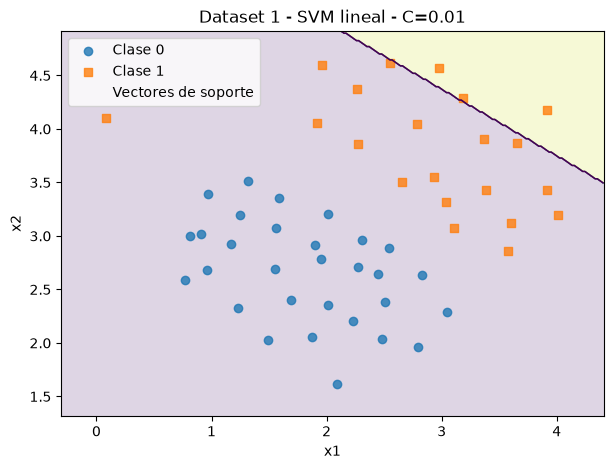

C: 1
Accuracy entrenamiento: 0.9803921568627451
Vectores de soporte: 11


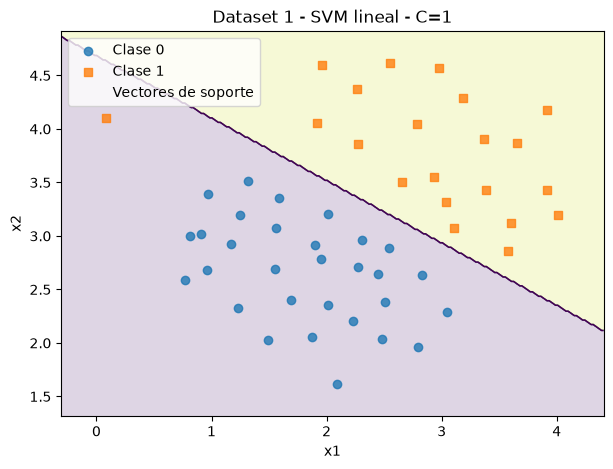

C: 100
Accuracy entrenamiento: 1.0
Vectores de soporte: 3


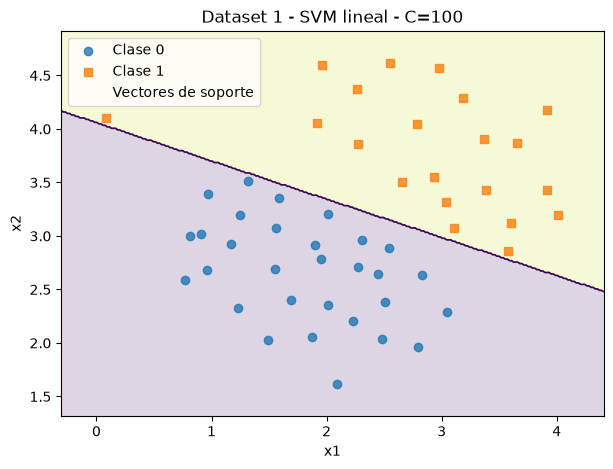

In [18]:
for C in [0.01, 1, 100]:

    svm_linear = Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(
            kernel='linear',
            C=C
        ))
    ])

    svm_linear.fit(
        X_svm1,
        y_svm1
    )

    print('C:', C)
    print('Accuracy entrenamiento:',
          svm_linear.score(X_svm1, y_svm1))
    print('Vectores de soporte:',
          len(svm_linear.named_steps['svc'].support_))

    plot_decision_boundary(
        svm_linear,
        X_svm1,
        y_svm1,
        f'Dataset 1 - SVM lineal - C={C}'
    )

¿Qué ocurre con el margen cuando disminuye C?
Cuando disminuye C, la penalización por las violaciones del margen disminuye. Esto permite que el modelo tolere más muestras dentro del margen o incluso algunos errores de clasificación, favoreciendo un margen más amplio. En consecuencia, con C=0.01 se obtiene una frontera más tolerante y aparecen muchos vectores de soporte.

¿Qué ocurre con el ajuste al outlier cuando aumenta C?
Cuando aumenta C, el modelo penaliza más fuertemente las violaciones del margen. Por lo tanto, intenta ajustar con mayor precisión las muestras de entrenamiento, incluyendo la observación atípica. Esto se observa claramente al pasar de C=1 a C=100: el accuracy de entrenamiento aumenta hasta alcanzar 100 % y disminuye notablemente el número de vectores de soporte.

¿Qué riesgo aparece con un C excesivamente grande?
Un C excesivamente grande puede provocar sobreajuste. La SVM puede intentar ajustar demasiado las muestras individuales y, especialmente, los datos atípicos, produciendo una frontera que represente muy bien el conjunto de entrenamiento pero que generalice peor frente a nuevos datos.

¿Por qué no debería elegirse solamente observando el accuracy de entrenamiento?
No debería elegirse una configuración únicamente observando el accuracy de entrenamiento porque ese valor solamente mide qué tan bien el modelo se ajusta a los datos utilizados para entrenarlo. Un modelo puede obtener accuracy de entrenamiento muy alto debido al sobreajuste y, sin embargo, presentar un peor desempeño sobre datos nuevos. Para seleccionar hiperparámetros es necesario utilizar datos de validación o validación cruzada y reservar el conjunto de prueba para la evaluación final.

## 12. Dataset 2: SVM con kernel RBF y efecto de γ
Mantenga C=1 y compare γ ∈ {0.01, 1, 100}.
Use la función plot_decision_boundary provista al inicio de la notebook

Dimensiones: (863, 2)
Cantidad por clase: [383 480]


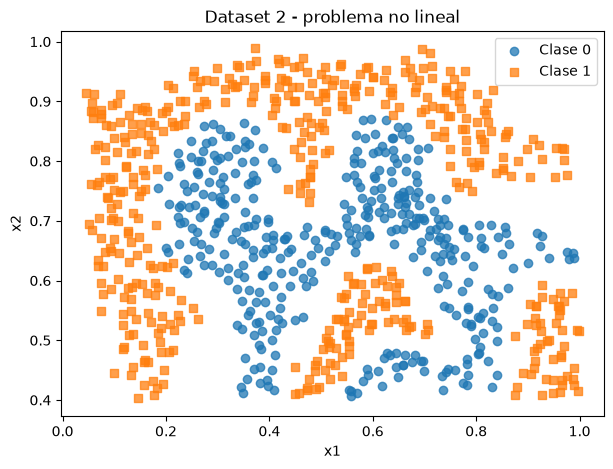

In [19]:
mat2 = sio.loadmat(DATA_DIR / 'data2.mat')
X_svm2 = mat2['X']
y_svm2 = mat2['y'].ravel()
print('Dimensiones:', X_svm2.shape)
print('Cantidad por clase:', np.bincount(y_svm2.astype(int)))
plot_labeled_points(X_svm2, y_svm2, 'Dataset 2 - problema no lineal')

Gamma: 0.01
Accuracy entrenamiento: 0.6512166859791425
Vectores de soporte: 760


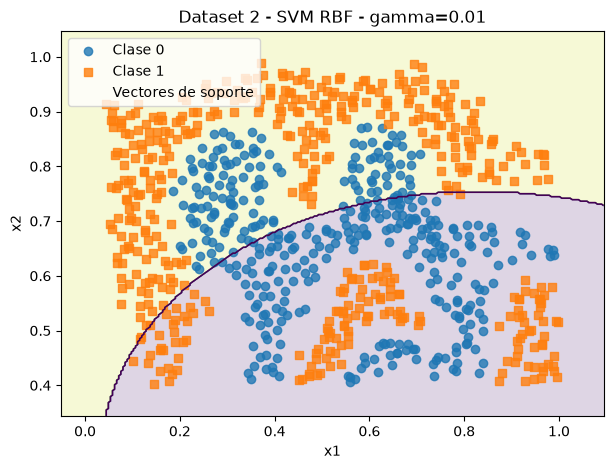

Gamma: 1
Accuracy entrenamiento: 0.9432213209733488
Vectores de soporte: 294


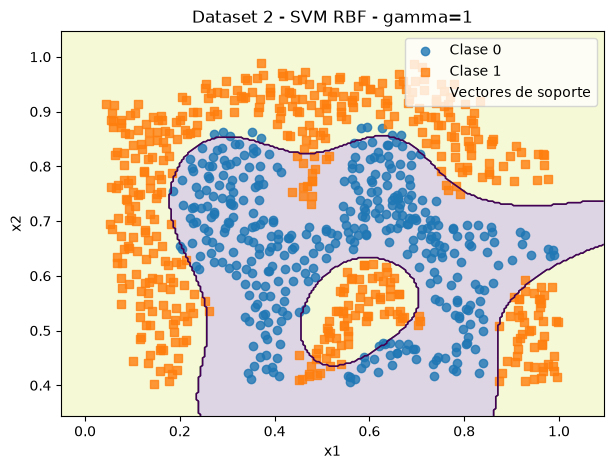

Gamma: 100
Accuracy entrenamiento: 1.0
Vectores de soporte: 713


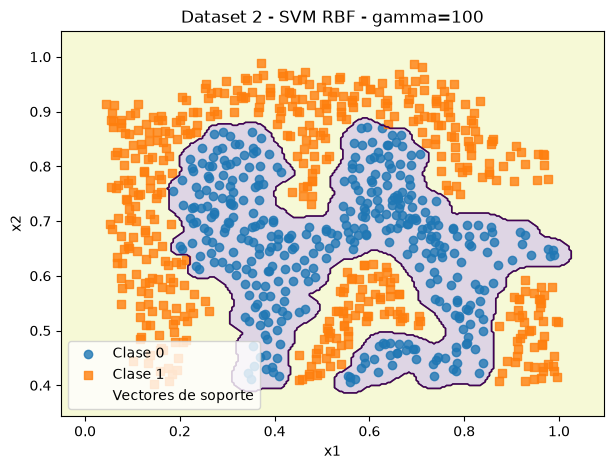

In [20]:
for gamma in [0.01, 1, 100]:

    svm_rbf = Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(
            kernel='rbf',
            C=1,
            gamma=gamma
        ))
    ])

    svm_rbf.fit(
        X_svm2,
        y_svm2
    )

    print('Gamma:', gamma)
    print('Accuracy entrenamiento:',
          svm_rbf.score(X_svm2, y_svm2))
    print('Vectores de soporte:',
          len(svm_rbf.named_steps['svc'].support_))

    plot_decision_boundary(
        svm_rbf,
        X_svm2,
        y_svm2,
        f'Dataset 2 - SVM RBF - gamma={gamma}'
    )

¿Qué comportamiento se observa con un γ demasiado pequeño?
Con un γ demasiado pequeño, cada muestra tiene una influencia muy amplia. Como consecuencia, la frontera resulta más suave y el modelo tiene menor capacidad para representar estructuras locales de los datos. En este caso, con γ=0.01, el accuracy de entrenamiento es solamente aproximadamente 65,12 % y se utilizan muchos vectores de soporte.

¿Qué comportamiento se observa con un γ demasiado grande?
Con un γ demasiado grande, la influencia de cada muestra se vuelve muy local. Esto permite construir fronteras mucho más complejas y ajustadas a los datos de entrenamiento. En este caso, γ=100 alcanza un accuracy de entrenamiento del 100 %, pero utiliza una cantidad elevada de vectores de soporte. Esto puede ser indicativo de un modelo demasiado complejo y con riesgo de sobreajuste

¿La configuración que obtiene el mayor accuracy de entrenamiento puede considerarse automáticamente la mejor? Justifique.
No. El mayor accuracy de entrenamiento no implica automáticamente que una configuración sea la mejor. Un modelo con parámetros demasiado flexibles puede memorizar el conjunto de entrenamiento y obtener un accuracy perfecto, pero presentar peor capacidad de generalización. La selección debe realizarse utilizando un conjunto de validación o validación cruzada y dejando el conjunto de prueba aislado hasta el final.

## 13 Entrenamiento Validación y Prueba

Train: (211, 2) [105 106]
Validation: (100, 2) [56 44]
Test: (100, 2) [57 43]


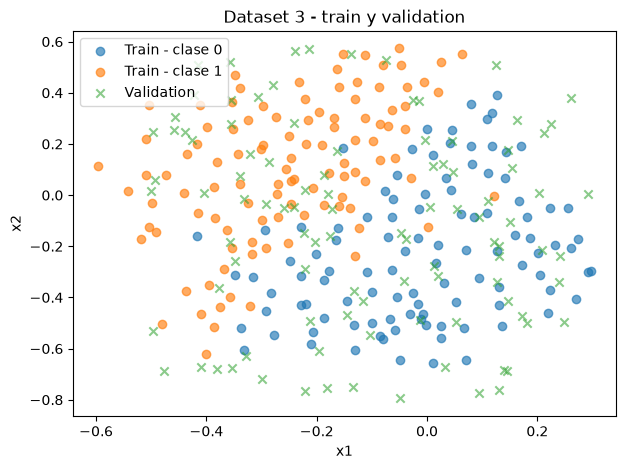

In [21]:
# Código provisto
mat3 = sio.loadmat(DATA_DIR / 'data3_train_val_test.mat')

X_train_3 = mat3['X_train']
y_train_3 = mat3['y_train'].ravel()
X_val_3 = mat3['X_val']
y_val_3 = mat3['y_val'].ravel()
X_test_3 = mat3['X_test']
y_test_3 = mat3['y_test'].ravel()

print('Train:', X_train_3.shape, np.bincount(y_train_3.astype(int)))
print('Validation:', X_val_3.shape, np.bincount(y_val_3.astype(int)))
print('Test:', X_test_3.shape, np.bincount(y_test_3.astype(int)))

plt.figure(figsize=(7, 5))
for label in np.unique(y_train_3):
    plt.scatter(
        X_train_3[y_train_3 == label, 0],
        X_train_3[y_train_3 == label, 1],
        alpha=0.65,
        label=f'Train - clase {label}',
    )
plt.scatter(X_val_3[:, 0], X_val_3[:, 1], marker='x', alpha=0.55, label='Validation')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Dataset 3 - train y validation')
plt.legend()
plt.show()

## 14. Selección manual con un único conjunto de validación
Entrenar cada combinación de C y γ usando solamente train; medir su accuracy en validation; ordenar las configuraciones de mayor a menor desempeño.

In [22]:
valores_C = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]
valores_gamma = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 300]

In [23]:
resultados = []

for C in valores_C:
    for gamma in valores_gamma:

        modelo = Pipeline([
            ('scaler', StandardScaler()),
            ('svc', SVC(
                kernel='rbf',
                C=C,
                gamma=gamma
            ))
        ])

        modelo.fit(
            X_train_3,
            y_train_3
        )

        y_val_pred = modelo.predict(X_val_3)

        accuracy = accuracy_score(
            y_val_3,
            y_val_pred
        )

        resultados.append({
            'C': C,
            'gamma': gamma,
            'validation_accuracy': accuracy
        })

resultados_df = pd.DataFrame(resultados)

resultados_df = resultados_df.sort_values(
    'validation_accuracy',
    ascending=False
)

resultados_df

,C,gamma,validation_accuracy
22,0.10,1.00,0.99
75,100.00,0.30,0.99
67,30.00,1.00,0.99
32,0.30,3.00,0.99
50,3.00,3.00,0.98
...,...,...,...
0,0.01,0.01,0.44
35,0.30,300.00,0.44
17,0.03,300.00,0.44
25,0.10,30.00,0.44


¿Hay una única combinación ganadora o aparecen empates?
No hay una única combinación ganadora. En el conjunto de validación aparecen cuatro configuraciones que obtienen el mismo mejor accuracy: (C=0.1, gamma=1), (C=0.3, gamma=3), (C=30, gamma=1) y (C=100, gamma=0.3). Todas alcanzan una accuracy de 0.99

Si varias configuraciones obtienen el mismo accuracy de validación, ¿qué problema aparece al elegir una?
Aparece un problema de desempate. El accuracy por sí solo no permite establecer cuál de las configuraciones es preferible. En ese caso pueden considerarse otros criterios, como la estabilidad observada mediante validación cruzada o la complejidad del modelo

¿Podemos utilizar el conjunto de test para desempatar?
No debemos utilizar el conjunto de test para desempatar. El test debe permanecer aislado hasta que finalice completamente la selección de hiperparámetros. Utilizarlo para decidir entre configuraciones convertiría al conjunto de prueba en parte del proceso de selección y dejaría de proporcionar una evaluación final independiente.

¿Qué limitación tiene basar toda la decisión en un único conjunto de validación de 100 muestras?
La principal limitación de basar toda la decisión en un único conjunto de validación de 100 muestras es que el resultado puede depender de cuáles muestras quedaron dentro de ese conjunto. Una configuración puede obtener un accuracy ligeramente mayor debido a las características particulares de esa partición y no necesariamente porque generalice mejor. La validación cruzada permite reducir esta dependencia al evaluar el modelo sobre varias particiones

## 15. Validación cruzada para seleccionar hiperparámetros
Combinar train y validation en un conjunto train_val.
Para cada combinación de C y γ, calcular el accuracy medio de una validación cruzada de 5 particiones utilizando cross_val_score.

In [24]:
# Código provisto
X_train_val_3 = np.vstack([X_train_3, X_val_3])
y_train_val_3 = np.concatenate([y_train_3, y_val_3])

print('Train+Val:', X_train_val_3.shape)
print('Test reservado:', X_test_3.shape)

Train+Val: (311, 2)
Test reservado: (100, 2)


In [25]:
resultados_cv = []

for C in valores_C:
    for gamma in valores_gamma:

        modelo = Pipeline([
            ('scaler', StandardScaler()),
            ('svc', SVC(
                kernel='rbf',
                C=C,
                gamma=gamma
            ))
        ])

        scores = cross_val_score(
            modelo,
            X_train_val_3,
            y_train_val_3,
            cv=5
        )

        resultados_cv.append({
            'C': C,
            'gamma': gamma,
            'cv_mean': scores.mean(),
            'cv_std': scores.std()
        })

resultados_cv_df = pd.DataFrame(resultados_cv)

resultados_cv_df = resultados_cv_df.sort_values(
    'cv_mean',
    ascending=False
)

resultados_cv_df

,C,gamma,cv_mean,cv_std
75,100.00,0.3,0.951971,0.036153
32,0.30,3.0,0.948746,0.033806
40,1.00,1.0,0.948746,0.035311
41,1.00,3.0,0.945520,0.032587
42,1.00,10.0,0.945520,0.032587
...,...,...,...,...
4,0.01,1.0,0.517665,0.003072
35,0.30,300.0,0.517665,0.003072
17,0.03,300.0,0.517665,0.003072
25,0.10,30.0,0.517665,0.003072



 ¿La mejor combinación obtenida con validación cruzada coincide necesariamente con alguna de las mejores del hold-out validation?
La mejor combinación obtenida mediante validación cruzada no necesariamente coincide con alguna de las mejores configuraciones encontradas mediante hold-out validation. En este ejercicio, la selección mediante hold-out produjo un empate entre cuatro configuraciones con accuracy 0.99, mientras que la validación cruzada seleccionó C=100 y gamma=0.3 como la configuración con mayor accuracy medio.

 ¿Por qué el mejor accuracy medio de CV puede ser menor que el obtenido con hold-out?
El mejor accuracy medio de validación cruzada puede ser menor que el obtenido mediante hold-out porque representan procedimientos diferentes. Hold-out mide el desempeño sobre una única partición de validación, mientras que la validación cruzada promedia el desempeño sobre cinco particiones diferentes. Por lo tanto, la media de CV puede ser más conservadora y reflejar mejor la variabilidad del modelo frente a diferentes subconjuntos de los datos.

  ¿Qué información adicional aporta `cv_std`?
  cv_std aporta información sobre la estabilidad del modelo entre los distintos folds. Un valor pequeño indica que el desempeño es relativamente consistente entre las particiones, mientras que un valor mayor indica una mayor variabilidad y, por lo tanto, una mayor dependencia respecto de los datos utilizados en cada fold

## 16. Automatización con GridSearchCV
Repita la búsqueda anterior con GridSearchCV y compare los resultados con la búsqueda manual.¿Llega al mismo resultado?

In [26]:
param_grid = {
    'svc__C': valores_C,
    'svc__gamma': valores_gamma,
}

In [27]:
grid_search = GridSearchCV(
    Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(
            kernel='rbf'
        ))
    ]),
    param_grid,
    cv=5,
    refit=True
)

grid_search.fit(
    X_train_val_3,
    y_train_val_3
)

print('Mejores parámetros:',
      grid_search.best_params_)

print('Mejor score:',
      grid_search.best_score_)

Mejores parámetros: {'svc__C': 100, 'svc__gamma': 0.3}
Mejor score: 0.9519713261648747


Sí, GridSearchCV llega al mismo resultado que la búsqueda manual mediante validación cruzada.
La mejor configuración encontrada fue C=100 y gamma=0.3, con un accuracy medio de validación cruzada de aproximadamente 0.95197, equivalente al 95,20 %.
Esto ocurre porque GridSearchCV automatiza el procedimiento que realizamos manualmente: genera todas las combinaciones de valores de C y gamma, evalúa cada una mediante validación cruzada y selecciona la configuración con mayor score medio.
Además, como se utiliza refit=True, una vez seleccionada la mejor combinación, el mejor pipeline se vuelve a ajustar utilizando todos los datos de train_val.

## 17. Evaluación final sobre test
Evalúe grid_search.best_estimator_ sobre test, muestre la matriz de confusión y grafique la frontera de decisión.
Use la función plot_decision_boundary provista al inicio de la notebook

Test accuracy: 0.93
Matriz de confusión:
[[53  4]
 [ 3 40]]


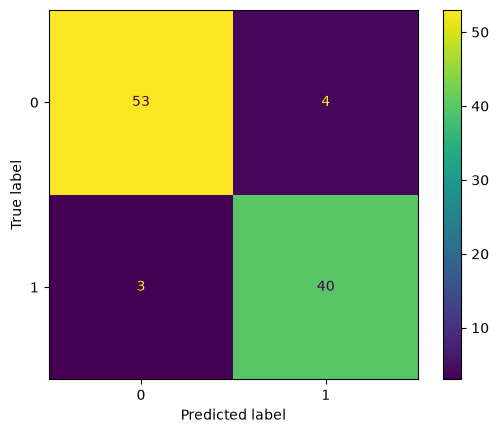

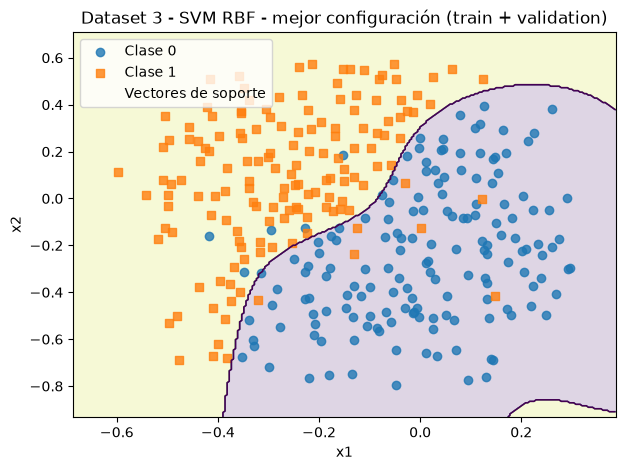

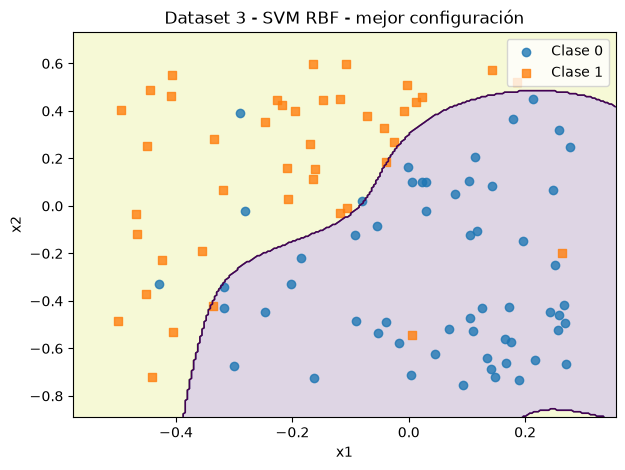

In [31]:
best_model = grid_search.best_estimator_

y_test_pred_3 = best_model.predict(
    X_test_3
)

test_accuracy_3 = accuracy_score(
    y_test_3,
    y_test_pred_3
)

cm_3 = confusion_matrix(
    y_test_3,
    y_test_pred_3
)

print('Test accuracy:', test_accuracy_3)
print('Matriz de confusión:')
print(cm_3)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_3
)

disp.plot()
plt.show()


plot_decision_boundary(
    best_model,
    X_train_val_3,
    y_train_val_3,
    'Dataset 3 - SVM RBF - mejor configuración (train + validation)'
)

plot_decision_boundary(
    best_model,
    X_test_3,
    y_test_3,
    'Dataset 3 - SVM RBF - mejor configuración',
    show_support=False
)

La configuración seleccionada mediante validación cruzada fue C=100 y gamma=0.3. Una vez finalizada la selección, el modelo se evaluó sobre el conjunto de test reservado.

La accuracy obtenida sobre test fue 0.93, equivalente al 93 %.

La matriz de confusión fue:

[[53, 4], [3, 40]]

Esto significa que 53 muestras de la clase 0 fueron clasificadas correctamente y 40 muestras de la clase 1 también fueron clasificadas correctamente. Hubo 4 muestras de la clase 0 clasificadas como clase 1 y 3 muestras de la clase 1 clasificadas como clase 0.

En total se clasificaron incorrectamente 7 de las 100 muestras de test.

La diferencia entre el 95,20 % obtenido como promedio durante la validación cruzada y el 93 % obtenido sobre test muestra que el desempeño puede variar al evaluar sobre un conjunto independiente. El resultado de test constituye la estimación final del modelo seleccionado



¿Por qué el test debe utilizarse recién después de finalizar la selección de hiperparámetros?
El test debe utilizarse recién después de finalizar la selección de hiperparámetros porque su función es proporcionar una evaluación final e independiente del procedimiento seleccionado. Si se utilizara durante la selección, la información del test influiría en las decisiones y la estimación final dejaría de ser independiente.

¿Qué ocurriría si, al ver el resultado de test, modificáramos nuevamente $C$ o $\gamma$ para mejorarlo?
Si después de observar el resultado de test modificáramos nuevamente C o gamma para mejorar ese resultado, estaríamos utilizando el conjunto de test para seleccionar el modelo. Esto produciría fuga de información y convertiría al test en parte del proceso de ajuste. En consecuencia, ya no podríamos considerar el resultado obtenido como una evaluación final imparcial

## PARTE D — COMPARAR LDA Y SVM SOBRE EL MISMO PROBLEMA

## 18. Comparación de clasificadores

Sobre X_train, y_train:
estime el desempeño de LDA con cross_val_score(cv=5);
seleccione para SVM lineal mediante GridSearchCV;
seleccione C y gamma para SVM RBF mediante GridSearchCV;
compare los mejores scores medios de validación cruzada.

¿Qué modelo obtiene el mejor score medio de CV en esta ejecució

In [ ]:
lda_cv_scores = cross_val_score(
    Pipeline([
        ('scaler', StandardScaler()),
        ('lda', LinearDiscriminantAnalysis())
    ]),
    X_train,
    y_train,
    cv=5
)

print('LDA:')
print(lda_cv_scores)
print('Media:', lda_cv_scores.mean())

LDA:
[0.96 0.96 1.   1.   1.  ]
Media: 0.984


In [ ]:
grid_linear = GridSearchCV(
    Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(
            kernel='linear'
        ))
    ]),
    {
        'svc__C': valores_C
    },
    cv=5,
    refit=True
)

grid_linear.fit(
    X_train,
    y_train
)

print('SVM lineal:')
print('Mejores parámetros:', grid_linear.best_params_)
print('Mejor score:', grid_linear.best_score_)

SVM lineal:
Mejores parámetros: {'svc__C': 0.1}
Mejor score: 0.9836666666666666


In [ ]:
grid_rbf = GridSearchCV(
    Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(
            kernel='rbf'
        ))
    ]),
    {
        'svc__C': valores_C,
        'svc__gamma': valores_gamma
    },
    cv=5,
    refit=True
)

grid_rbf.fit(
    X_train,
    y_train
)

print('SVM RBF:')
print('Mejores parámetros:', grid_rbf.best_params_)
print('Mejor score:', grid_rbf.best_score_)

SVM RBF:
Mejores parámetros: {'svc__C': 1, 'svc__gamma': 0.1}
Mejor score: 0.992


En esta ejecución, el modelo que obtuvo el mejor score medio de validación cruzada fue la SVM con kernel RBF.

Los resultados fueron:

LDA: accuracy medio de CV = 0.9840.
SVM lineal: accuracy medio de CV = 0.9837, con C=0.1.
SVM RBF: accuracy medio de CV = 0.9920, con C=1 y gamma=0.1.

Por lo tanto, la SVM con kernel RBF presentó el mejor desempeño promedio durante la validación cruzada.

La SVM lineal y LDA tuvieron desempeños muy similares, lo cual resulta razonable porque ambos generan reglas de decisión lineales. La SVM RBF, en cambio, puede representar fronteras no lineales y en esta ejecución logró una mejora respecto de los otros dos modelos.

## 19. Evaluación del modelo seleccionado en Wine
Seleccione el candidato con mejor score de validación cruzada y evalúelo una sola vez sobre el test reservado al comienzo.
Comente el resultado.
Como el mejor candidato fue SVM RBF con C=1 y gamma=0.1, utilizamos el mejor estimador obtenido por GridSearchCV.

In [ ]:
best_wine_model = grid_rbf.best_estimator_

best_wine_model.fit(
    X_train,
    y_train
)

y_test_wine_pred = best_wine_model.predict(
    X_test
)

wine_test_accuracy = accuracy_score(
    y_test,
    y_test_wine_pred
)

wine_test_cm = confusion_matrix(
    y_test,
    y_test_wine_pred
)

print('Test accuracy:', wine_test_accuracy)
print('Matriz de confusión:')
print(wine_test_cm)

Test accuracy: 0.9814814814814815
Matriz de confusión:
[[18  0  0]
 [ 0 21  0]
 [ 0  1 14]]


El modelo seleccionado fue la SVM con kernel RBF, utilizando C=1 y gamma=0.1, ya que obtuvo el mejor score medio de validación cruzada, con un valor de 0.992.

Al evaluar este modelo una única vez sobre el conjunto de test reservado, se obtuvo una accuracy de 0.98148, equivalente al 98,15 %.

La matriz de confusión fue:

[[18, 0, 0], [0, 21, 0], [0, 1, 14]]

De las 54 muestras del conjunto de prueba, 53 fueron clasificadas correctamente y solamente una fue clasificada incorrectamente. La única confusión correspondió a una muestra de la clase 2 que fue predicha como clase 1.

El resultado de test es ligeramente inferior al score medio obtenido mediante validación cruzada, pero continúa siendo muy alto. Esto muestra que el modelo seleccionado presenta un buen desempeño sobre datos que no participaron en la selección de hiperparámetros.

## 20. LDA como transformación antes de otro clasificador
Evalúe el pipeline:
Scaler → LDA(n_components=2) → SVM lineal con validación cruzada.
Compare con los resultados de los modelos en 19 y comente el resultado.

In [ ]:
lda_svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis(
        n_components=2
    )),
    ('svc', SVC(
        kernel='linear'
    ))
])

lda_svm_scores = cross_val_score(
    lda_svm_pipeline,
    X_train,
    y_train,
    cv=5
)

print('Accuracies:', lda_svm_scores)
print('Media:', lda_svm_scores.mean())
print('Desviación estándar:', lda_svm_scores.std())

Accuracies: [0.96 1.   1.   1.   1.  ]
Media: 0.992
Desviación estándar: 0.016000000000000014


El pipeline compuesto por StandardScaler → LDA(n_components=2) → SVM lineal obtuvo los siguientes accuracies en las cinco particiones:

[0.96, 1.00, 1.00, 1.00, 1.00]

La media fue 0.992 y la desviación estándar fue 0.016.

El accuracy medio coincide con el obtenido por la SVM RBF seleccionada anteriormente mediante GridSearchCV, que también alcanzó 0.992 de media en validación cruzada.

El resultado muestra que, para este dataset, la información discriminante puede concentrarse en solamente dos dimensiones mediante LDA sin perder capacidad de clasificación en términos del accuracy medio observado. La SVM lineal aplicada sobre esa representación obtuvo un desempeño muy alto.

Sin embargo, no debe concluirse únicamente a partir de este resultado que el pipeline LDA + SVM sea siempre superior. La comparación depende del dataset, de la partición utilizada y de las configuraciones evaluadas.

Es importante además que LDA se encuentre dentro del Pipeline. Como LDA es una transformación supervisada que utiliza las etiquetas de clase, debe ajustarse independientemente dentro de cada fold de la validación cruzada. De esta manera se evita utilizar información de las muestras de validación al construir la representación LDA y se evita la fuga de información.